In [72]:
import numpy as np
import pandas as pd
import pre_processing
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, make_scorer, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [73]:
mental_health = pd.read_csv("Teen_Mental_Health_Dataset.csv")

processed_data = pre_processing.transform(mental_health)

In [74]:
X = processed_data.drop("depression_label", axis=1)
y = processed_data["depression_label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


Logistic Regression: The Mean F1 is: 0.5106251047427518, Standard Deviation: 0.05431211517700366
RandomForestClassifier: The Mean F1 is: 0.8952380952380952, Standard Deviation: 0.07678340712665285


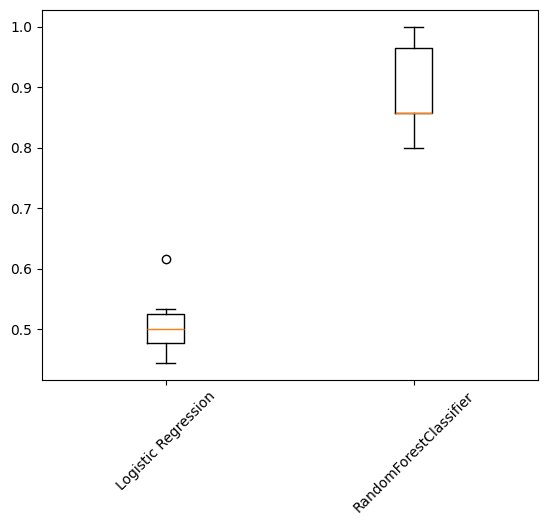

In [75]:
models = {
    "Logistic Regression": Pipeline([
        ("smote", SMOTE(sampling_strategy="minority", random_state=42)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
        ]),
    
    "RandomForestClassifier": Pipeline([
        ("smote", SMOTE(sampling_strategy="minority", random_state=42)),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
    ]),
}

sf = StratifiedKFold(n_splits=6, random_state=12, shuffle=True)

result = []

for name, model in models.items():
    cvs_results = cross_val_score(
        model,
        X_train,
        y_train,
        cv=sf,
        scoring="f1"
    )
    print(f"{name}: The Mean F1 is: {cvs_results.mean()}, Standard Deviation: {cvs_results.std()}")
    result.append(cvs_results)

plt.boxplot(result, tick_labels=models.keys())
plt.xticks(rotation=45)
plt.show()

In [76]:
# Using RandomForestClassifier as a model
pipeline = Pipeline([
    ("smote", SMOTE(sampling_strategy="minority",random_state=42)),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
])

params = [{
    'model__n_estimators':[50, 100, 200, 300],
    'model__max_depth':[3,5,10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1,2,4],
}]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    cv=sf,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 6 folds for each of 144 candidates, totalling 864 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [50, 100, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more a

In [77]:
print("Beste Parameter:", grid_search.best_params_)
print(f"Bester CV F1-Score: {grid_search.best_score_:.3f}")

Beste Parameter: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Bester CV F1-Score: 0.929


In [78]:
y_pred = grid_search.predict(X_test)
y_prob = grid_search.predict_proba(X_test)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred,
      target_names=["No Depression (0)", "Depression (1)"]))

print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.3f}")


── Classification Report ──
                   precision    recall  f1-score   support

No Depression (0)       1.00      1.00      1.00       351
   Depression (1)       1.00      1.00      1.00         9

         accuracy                           1.00       360
        macro avg       1.00      1.00      1.00       360
     weighted avg       1.00      1.00      1.00       360

ROC-AUC:  1.000


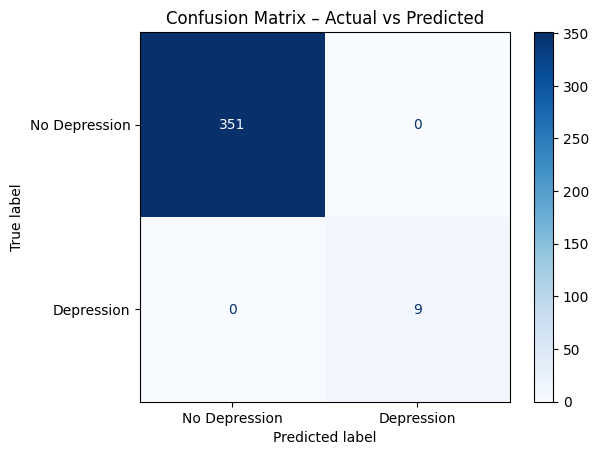

In [79]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Depression", "Depression"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix – Actual vs Predicted")
plt.show()


# **Schlussfolgerung**

## Modelleregbnisse
Im Rahmen dieses Projektes wurden zwei Machine-Learning Modelle, Logistische Regression (LR) und Random Forest Classifier (FR), zur binären Klassifikation von Depressionen bei Jugendlichen verglichen. Als Grundlage dienten Social-Media-Verhaltensdaten sowie psychologische und soziale Merkmal aus dem Teen Mental Health Dataset.
Bereits im initialen Modellvergleich mittels Stratified-K-Fold-Kreuzvalidierung (k=6) zeigte der Random forest mit einem mittleren F1-Score von 0.895 eine deutlich überlegene Leistung gegenüber der LR mit F1 = 0.511. Die schwache Leistung der LR deutet darauf hin, dass die Entscheidungsgrenzen zwischen den KLassen nicht-linear sind, was angesichts der EDA beobachteten Merkmalsüberlappung plausibel ist. Nach der Hyperparameteroptimierung per GridSearchCV konnte der RF seine Cross-Validation-F1-Score auf 0.929 verbessern. Die abschließende Evaluation auf dem Testdatensatz lieferte eine Accuracy von 100%, einen F1-Score von 1.0 sowie einen ROC-AUC-Wert von 1.0.

## Ursachenanalyse
Die perfekte Testmetriken sind mit hoher Wahrscheinlichkeit kein Zeichen chter Generalisierbarkeit, sondern weisen auf strukturelle Besonderheiten des Datensatzes hin. Die Erkenntnisse aus der explorativen Datenanalyse liefern hierfür konkrete Anhaltspunkte:

Die EDA zeigte eine deutliche Ungleichverteilung der Zielvariable `depression_label` zugunsten der Klasse *No Depression*. Durch den Einsatz von SMOTE wurde dieses Unglkeichgewicht im Training ausgeglichen. Da SMOTE synthetische Samples durch INterpolation erzeigt, kann es bei einem ohnehin synthetischen generierten Datensatz dazu führen, dass die künstlichen Trainingsdaten den echten Testdaten strukturell zu ähnlich sind, was die überhöhten Metriken begünstigt.

Die bivariate Analyse ergebab, dass die Merkmale `stress_level`, `anxiety_level`, `sleep_hours` und `daily_social_media_hours` klare Unterschiede zwischen depressiven und nicht-depressiven Jugendlichen zeigen. Das klingt zunächst positiv, bedeutet aber auch, dass das Modell möglicherweise nur auf wenigen, sehr dominanten Merkmalen basiert, anstatt ein breites, robustes Muster zu erlernen. Gerade bei einem synthetischen Datensatz besteht die Gefahr, dass diese Trennlinien künstlich eingebaut wurden und in echten Daten so nicht existieren.

## Ausblick & Handlungsempfehlung
Ein Klassenungleichgewicht zwischen *Depression* und *No Depression* ist kein Fehler des Datensatzes, es ist die Realität. In der echten Welt ist die Mehrheit der Menschen nicht von Depressionen betroffen und das sollte sich auch in den Daten widerspiegeln. Ein ausgeglichener Datensatz würde ein gesellschaftliches Problem widerspiegel, das wir uns nicht wünschen.
Für zukünftige Modelle bedeutet das: Das Ungleichgewicht muss methodisch korrekt behandelt werden, etwa durch geeignete Evaluationsmetriken (F1-Score, Recall), angepasste Klassifikationsschwellen oder Verfahren wie SMOTE, ohne die natürliche Verteilung zu ignorieren oder zu verzerren.

Im medizinischen Kontext ist ein **falsch-negativer Befund**, also eine nicht erkannte Depression schwerwiegender als ein falsch-positiver. Der Klassifikationsschwellenwert sollte daher zugunsten eines höheren Recalls für die Depressionsklasse angepasst werdem, auch wenn dadurch die Precision leicht sinkt.


